In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

## Understanding the data

In [70]:
data = pd.read_csv(r"C:\Users\KAVYA\Desktop\Salary_Prediction\Salary Data.csv")
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [71]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 375
Columns: 6


In [72]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [73]:
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [74]:
data.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [76]:
data.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [77]:
data["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD', nan], dtype=object)

## Data Cleaning

In [78]:
data.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [79]:
data.duplicated().sum()

50

In [80]:
data = data.drop_duplicates()

In [81]:
data.isnull().sum()

Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
Salary                 1
dtype: int64

In [82]:
data = data.dropna()

In [83]:
data.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [84]:
print("Negative Age:", (data["Age"] < 0).sum())
print("Negative Experience:", (data["Years of Experience"] < 0).sum())
print("Negative Salary:", (data["Salary"] < 0).sum())

Negative Age: 0
Negative Experience: 0
Negative Salary: 0


## EDA

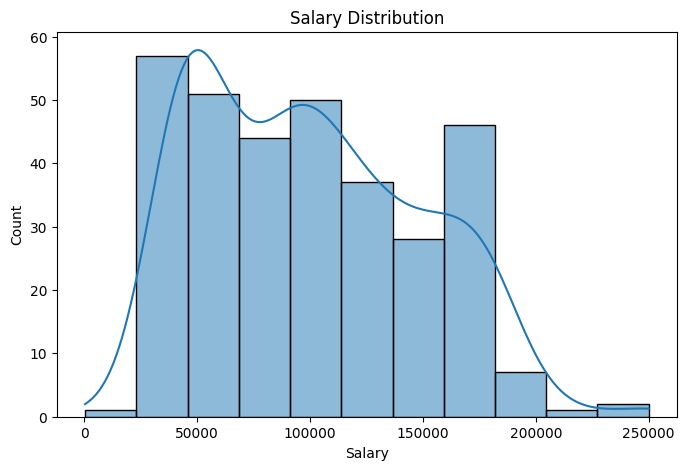

In [85]:
plt.figure(figsize=(8,5))

sns.histplot(data["Salary"], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

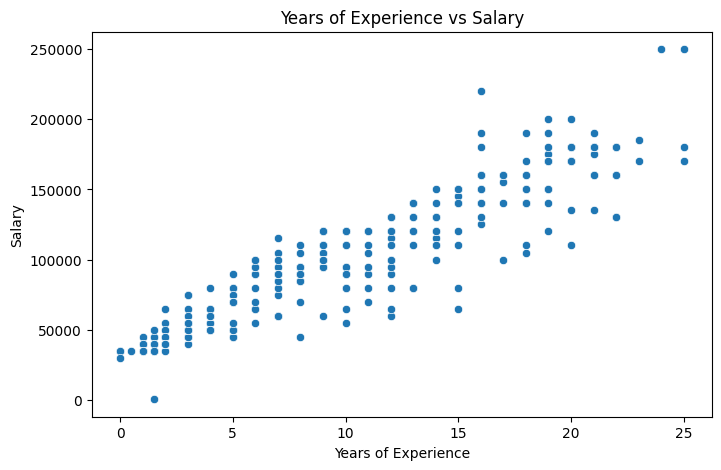

In [86]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Years of Experience",
    y="Salary"
)

plt.title("Years of Experience vs Salary")

plt.show()

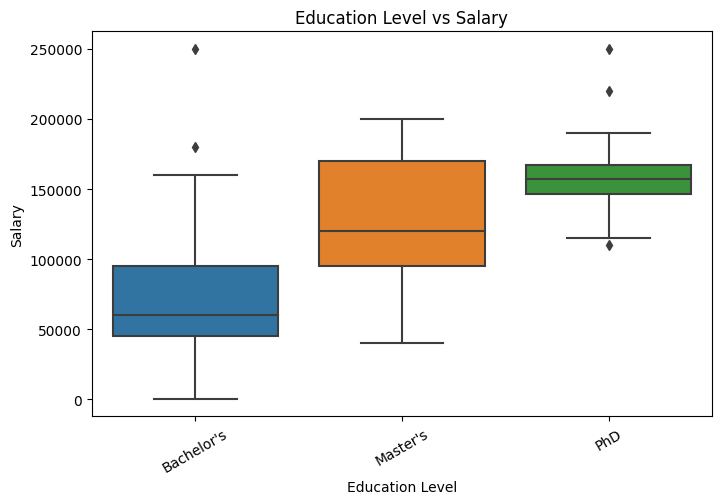

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x="Education Level",
    y="Salary"
)

plt.title("Education Level vs Salary")
plt.xticks(rotation=30)

plt.show()

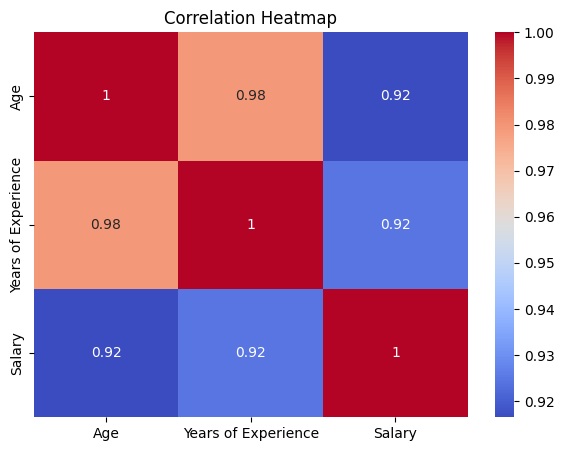

In [88]:
plt.figure(figsize=(7,5))

sns.heatmap(
    data[["Age", "Years of Experience", "Salary"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [89]:
X = data[
    [
        "Age",
        "Education Level",
        "Years of Experience",
        "Experience_Age_Ratio"
    ]
]

KeyError: "['Experience_Age_Ratio'] not in index"

In [ ]:
y = data["Salary"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (324, 4)
y shape: (324,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Preprocessing

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "education",
            OneHotEncoder(handle_unknown="ignore"),
            ["Education Level"]
        )
    ],
    remainder=StandardScaler()
)

## linearregression

In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('education',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education Level'])])),
                ('model', LinearRegression())])

In [ ]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('education',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education Level'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=StandardScaler(),
                                   transformers=[('education',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education Level'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return mae, rmse, r2

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

In [ ]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [ ]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder=StandardScaler(),
                                                          transformers=[('education',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Education '
                                                                          'Level'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='r2')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [ ]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("Final Model Performance")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

Final Model Performance
MAE: 11616.680632568328
RMSE: 16422.59285576673
R2 Score: 0.8572846788343403


In [ ]:
new_employee = pd.DataFrame({
    "Age": [25],
    "Education Level": ["Bachelor's"],
    "Years of Experience": [2],
    "Experience_Age_Ratio": [2/25]
})

predicted_salary = final_model.predict(new_employee)

print(
    "Predicted Salary:",
    predicted_salary[0]
)

Predicted Salary: 38243.80952380953


In [ ]:
data["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

In [90]:
import os

print(os.getcwd())

c:\Users\KAVYA\Desktop\Salary_Prediction


In [94]:
import joblib

joblib.dump(
    final_model,
    "model/salary_prediction_model.pkl"
)

['model/salary_prediction_model.pkl']

In [95]:
print("Model saved successfully!")

Model saved successfully!
